In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

In [2]:
!pip install -q kaggle
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
!kaggle datasets download -d adityajn105/flickr8k

Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0


In [3]:
!unzip "flickr8k.zip" -d "/content/dataset/"

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/Images/2844846111_8c1cbfc75d.jpg  
  inflating: /content/dataset/Images/2844963839_ff09cdb81f.jpg  
  inflating: /content/dataset/Images/2845246160_d0d1bbd6f0.jpg  
  inflating: /content/dataset/Images/2845691057_d4ab89d889.jpg  
  inflating: /content/dataset/Images/2845845721_d0bc113ff7.jpg  
  inflating: /content/dataset/Images/2846037553_1a1de50709.jpg  
  inflating: /content/dataset/Images/2846785268_904c5fcf9f.jpg  
  inflating: /content/dataset/Images/2846843520_b0e6211478.jpg  
  inflating: /content/dataset/Images/2847514745_9a35493023.jpg  
  inflating: /content/dataset/Images/2847615962_c330bded6e.jpg  
  inflating: /content/dataset/Images/2847859796_4d9cb0d31f.jpg  
  inflating: /content/dataset/Images/2848266893_9693c66275.jpg  
  inflating: /content/dataset/Images/2848571082_26454cb981.jpg  
  inflating: /content/dataset/Images/2848895544_6d06210e9d.jpg  
  inflating: /content/dataset/Images/28

In [4]:
df = pd.read_csv("dataset/captions.txt")
df.head(10)

,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...
5,1001773457_577c3a7d70.jpg,A black dog and a spotted dog are fighting
6,1001773457_577c3a7d70.jpg,A black dog and a tri-colored dog playing with...
7,1001773457_577c3a7d70.jpg,A black dog and a white dog with brown spots a...
8,1001773457_577c3a7d70.jpg,Two dogs of different breeds looking at each o...
9,1001773457_577c3a7d70.jpg,Two dogs on pavement moving toward each other .


In [5]:
df.shape # 31783 images x 5 descriptions for each image

(40455, 2)

In [6]:
!pip install tensorflow

In [7]:
!pip install opencv-python

In [8]:
import tensorflow as tf
import cv2

In [9]:
def read_image(image_name, image_folder="dataset/Images"):
    """
    Reads an image from the specified folder and returns it as an array.
    """
    img_path = os.path.join(image_folder, image_name)
    img = cv2.imread(img_path)
    if img is None:
        print(f"Error: Unable to read {image_name}")
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB format
    return img

In [10]:
def display_image_with_captions(image_name, captions_df, image_folder="dataset/Images"):
    """
    Reads and displays an image with all 5 captions.
    """
    # Read image
    img = read_image(image_name, image_folder)
    if img is None:
        return

    # Get all comments for this image
    comments = captions_df[captions_df["image"] == image_name]["caption"].tolist()

    # Display image
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis("off")

    # Show captions below the image
    caption_text = "\n".join(comments)  # Join comments as multi-line text
    plt.title(caption_text, fontsize=10, loc='center', pad=10)
    plt.show()

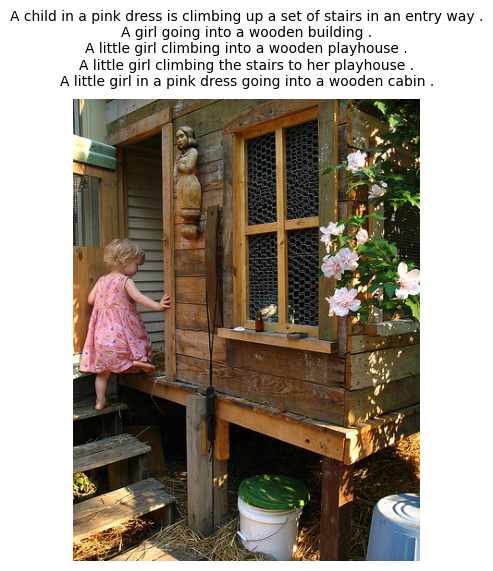

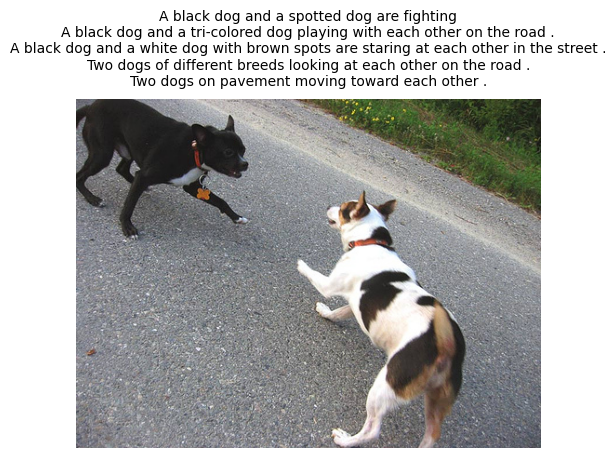

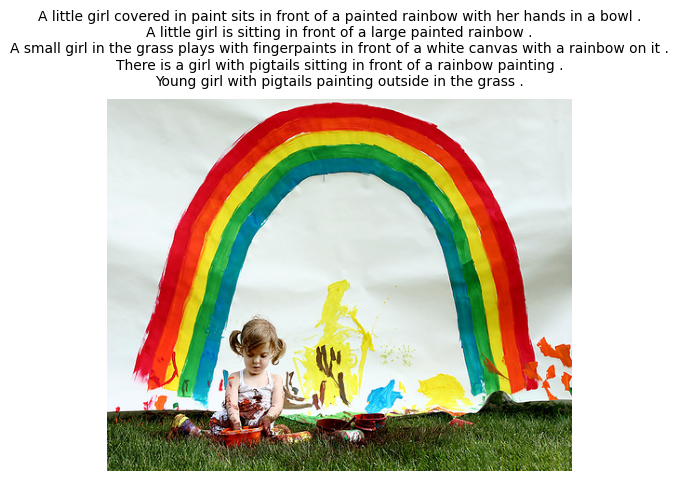

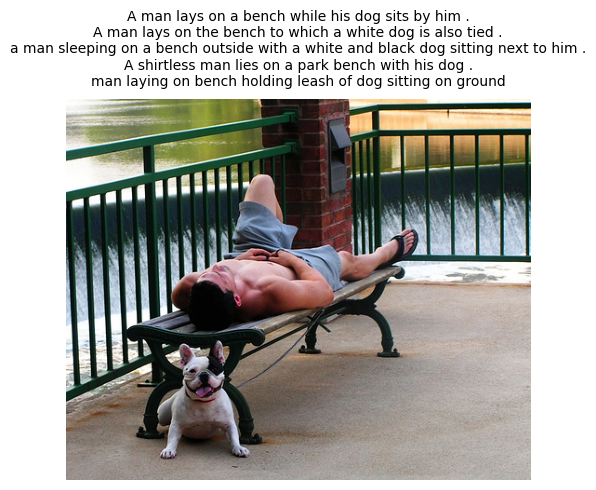

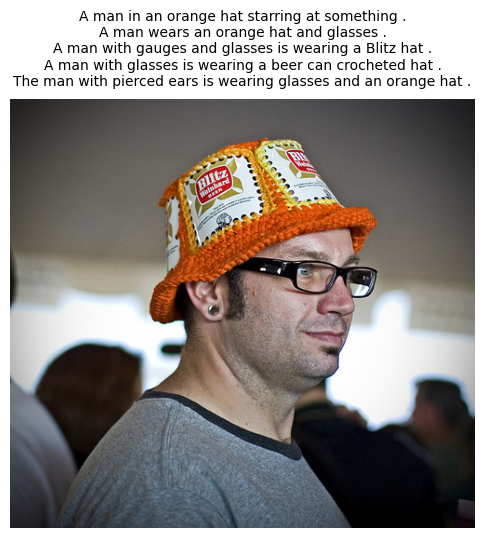

In [11]:
# Display first 5 images with their 5 captions each
for image_name in df["image"].unique()[:5]:
    display_image_with_captions(image_name, df)


In [12]:
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.9/289.9 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.3/118.3 kB 4.5 MB/s eta 0:00:00


In [13]:
import re
import nltk
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from contractions import fix

# Download necessary NLTK data
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

True

In [14]:
def preprocess_caption(text):
    # 1️⃣ Convert to lowercase
    text = text.lower()

    # 2️⃣ Expand contractions (e.g., "can't" → "cannot")
    text = fix(text)

    # 3️⃣ Remove special characters, numbers, and punctuations
    text = re.sub(r"[^a-zA-Z\s]", "", text)  # Keep only letters and spaces

    # 4️⃣ Tokenize words
    words = word_tokenize(text)

    # 6️⃣ Remove single-character words
    words = [word for word in words if len(word) > 1]

    # 7️⃣ Lemmatization (convert words to base form, e.g., "running" → "run")
    lemmatizer = WordNetLemmatizer()
    words = [lemmatizer.lemmatize(word) for word in words]

    # 8️⃣ Join words back into a sentence
    cleaned_text = " ".join(words)

    # 9️⃣ Remove extra spaces
    cleaned_text = re.sub(r"\s+", " ", cleaned_text).strip()

    return cleaned_text  # Removed adding <start> and <end> here

In [15]:
# Apply preprocessing function to all captions
df["caption"] = df["caption"].apply(preprocess_caption)
df['caption'] = "startseq "+df['caption']+" endseq"

In [16]:
df['caption'].values[:5]

array(['startseq child in pink dress is climbing up set of stair in an entry way endseq',
       'startseq girl going into wooden building endseq',
       'startseq little girl climbing into wooden playhouse endseq',
       'startseq little girl climbing the stair to her playhouse endseq',
       'startseq little girl in pink dress going into wooden cabin endseq'],
      dtype=object)

In [17]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [18]:
captions = df['caption'].tolist()
tokenizer = Tokenizer()
tokenizer.fit_on_texts(captions)
vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(caption.split()) for caption in captions)

images = df['image'].unique().tolist()
nimages = len(images)

split_index = round(0.85*nimages)
train_images = images[:split_index]
val_images = images[split_index:]

train = df[df['image'].isin(train_images)]
test = df[df['image'].isin(val_images)]

train.reset_index(inplace=True,drop=True)
test.reset_index(inplace=True,drop=True)

tokenizer.texts_to_sequences([captions[1]])[0]

[1, 14, 314, 66, 193, 105, 2]

In [19]:
captions[1]

'startseq girl going into wooden building endseq'

In [20]:
import os
import numpy as np
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
import torch

# 🔹 Load Pretrained CLIP Model & Processor
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
clip_model.to(device).eval()

# 🔹 Folder Paths
image_folder = "dataset/Images"  # Input images
save_folder = "dataset/clip_features"  # Feature dump
os.makedirs(save_folder, exist_ok=True)

# 🔹 Image List & Batch Settings
image_filenames = sorted(os.listdir(image_folder))
batch_size = 32
image_features = {}  # Initialize image_features as a dictionary
num_images = len(image_filenames)

# 🔹 Process in Batches
for i in range(0, num_images, batch_size):
    batch_files = image_filenames[i:i+batch_size]
    batch_images = []

    for img_name in batch_files:
        try:
            img_path = os.path.join(image_folder, img_name)
            img = Image.open(img_path).convert("RGB")
            batch_images.append(img)
        except Exception as e:
            print(f"⚠️ Skipping {img_name}: {e}")

    if not batch_images:
        continue

    # 🔹 Preprocess and Predict
    inputs = clip_processor(images=batch_images, return_tensors="pt", padding=True).to(device)

    with torch.no_grad():
        outputs = clip_model.get_image_features(**inputs)
        features = outputs.cpu().numpy()  # shape: (batch_size, 512)

    # 🔹 Save features and update image_features dictionary
    for j, img_name in enumerate(batch_files):
        feature = features[j]
        save_path = os.path.join(save_folder, img_name.replace(".jpg", ".npy"))
        np.save(save_path, feature)
        image_features[img_name.replace(".jpg", "")] = feature  # Store feature in dictionary

    print(f"✅ Processed {i + len(batch_images)}/{num_images} images.")

# 🔹 Save full dictionary (optional)
features_path = "dataset/clip_features.npy"
np.save(features_path, image_features)  # Save the dictionary
print(f"💾 All features saved to '{features_path}'")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

✅ Processed 32/8091 images.
✅ Processed 64/8091 images.
✅ Processed 96/8091 images.
✅ Processed 128/8091 images.
✅ Processed 160/8091 images.
✅ Processed 192/8091 images.
✅ Processed 224/8091 images.
✅ Processed 256/8091 images.
✅ Processed 288/8091 images.
✅ Processed 320/8091 images.
✅ Processed 352/8091 images.
✅ Processed 384/8091 images.
✅ Processed 416/8091 images.
✅ Processed 448/8091 images.
✅ Processed 480/8091 images.
✅ Processed 512/8091 images.
✅ Processed 544/8091 images.
✅ Processed 576/8091 images.
✅ Processed 608/8091 images.
✅ Processed 640/8091 images.
✅ Processed 672/8091 images.
✅ Processed 704/8091 images.
✅ Processed 736/8091 images.
✅ Processed 768/8091 images.
✅ Processed 800/8091 images.
✅ Processed 832/8091 images.
✅ Processed 864/8091 images.
✅ Processed 896/8091 images.
✅ Processed 928/8091 images.
✅ Processed 960/8091 images.
✅ Processed 992/8091 images.
✅ Processed 1024/8091 images.
✅ Processed 1056/8091 images.
✅ Processed 1088/8091 images.
✅ Processed 11

In [21]:
from tensorflow.keras.utils import Sequence , to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [22]:
features = np.load("dataset/clip_features.npy", allow_pickle=True).item()  # ✅ Convert back to dictionary

In [23]:
from tensorflow.keras.utils import Sequence, to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

class CustomDataGenerator(Sequence):
    def __init__(self, df, X_col, y_col, batch_size, features, max_length, vocab_size, tokenizer, shuffle=True):
        self.df = df.copy()
        self.X_col = X_col  # Image filename column
        self.y_col = y_col  # Caption text column
        self.batch_size = batch_size
        self.features = features  # Dictionary of image_name → feature vector (shape: 512, 768, or 2048)
        self.max_length = max_length
        self.vocab_size = vocab_size
        self.tokenizer = tokenizer
        self.shuffle = shuffle
        self.n = len(self.df)

        if self.shuffle:
            self.df = self.df.sample(frac=1).reset_index(drop=True)

    def on_epoch_end(self):
        """ Shuffle dataset after every epoch """
        if self.shuffle:
            self.df = self.df.sample(frac=1).reset_index(drop=True)

    def __len__(self):
        """ Total number of batches per epoch """
        return int(np.ceil(self.n / self.batch_size))

    def __getitem__(self, index):
        """ Generate one batch of data """
        batch = self.df.iloc[index * self.batch_size:(index + 1) * self.batch_size]
        X1, X2, y = self.__get_data(batch)
        return (X1, X2), y

    def __get_data(self, batch):
        X1, X2, y = [], [], []

        for _, row in batch.iterrows():
            image = row[self.X_col]
            caption = row[self.y_col]

            # Remove extension if necessary (depends on how keys are saved in features)
            image_key = image.replace(".jpg", "").replace(".png", "")

            feature = self.features.get(image_key, None)
            if feature is None:
                print(f"⚠️ Feature not found for image: {image_key}")
                continue

            # Tokenize caption
            seq = self.tokenizer.texts_to_sequences([caption])[0]

            # Create (in_seq, out_seq) pairs
            for i in range(1, len(seq)):
                in_seq = seq[:i]
                out_seq = seq[i]

                X1.append(feature)  # image feature vector
                X2.append(in_seq)   # partial caption sequence
                y.append(out_seq)   # next word

        # Final conversion
        X1 = np.array(X1)
        X2 = pad_sequences(X2, maxlen=self.max_length, padding='post')
        y = to_categorical(y, num_classes=self.vocab_size)

        return X1, X2, y


In [24]:
import tensorflow as tf
from tensorflow.keras.layers import Layer

class Attention(Layer):
    def __init__(self, units):
        super(Attention, self).__init__()
        self.W1 = tf.keras.layers.Dense(units)
        self.W2 = tf.keras.layers.Dense(units)
        self.V = tf.keras.layers.Dense(1)

    def call(self, features, hidden):
        hidden_with_time_axis = tf.expand_dims(hidden, 1)
        score = tf.nn.tanh(self.W1(features) + self.W2(hidden_with_time_axis))
        attention_weights = tf.nn.softmax(self.V(score), axis=1)
        context_vector = attention_weights * features
        context_vector = tf.reduce_sum(context_vector, axis=1)
        return context_vector, attention_weights

In [25]:
import tensorflow as tf
from tensorflow.keras.layers import Embedding, LSTM, Dense, Input, Dropout, Bidirectional, BatchNormalization, LayerNormalization

# Define model parameters
EMBEDDING_DIM = 512
LSTM_UNITS = 512
DROPOUT_RATE = 0.4

# CNN Encoder
image_input = Input(shape=(512,))  # Feature vector from CNN
image_features = Dense(LSTM_UNITS, activation="relu")(image_input)
image_features = BatchNormalization()(image_features)  # ? Normalizing CNN features
image_features = Dropout(DROPOUT_RATE)(image_features)

# Caption Decoder (BiLSTM)
caption_input = Input(shape=(max_length,))
caption_embedding = Embedding(vocab_size, EMBEDDING_DIM, mask_zero=True)(caption_input)
caption_embedding = LayerNormalization()(caption_embedding)  # ? LayerNormalization instead of BatchNorm
caption_embedding = Dropout(DROPOUT_RATE)(caption_embedding)

# BiLSTM Layer
bilstm_layer = Bidirectional(LSTM(LSTM_UNITS, return_sequences=False, return_state=True, dropout=DROPOUT_RATE))
lstm_output, forward_h, forward_c, backward_h, backward_c = bilstm_layer(caption_embedding)

# Normalize only the Dense output, not the LSTM output
hidden_state = tf.keras.layers.Concatenate()([forward_h, backward_h])  # Merging forward & backward LSTM states

# Merge Image Features & LSTM Output
merged = tf.keras.layers.Concatenate()([hidden_state, image_features])
merged = BatchNormalization()(merged)  # ? Batch Normalization after merging
merged = Dropout(DROPOUT_RATE)(merged)

# Fully Connected Layer
output = Dense(vocab_size, activation="softmax")(merged)

# Define Model
model = tf.keras.models.Model(inputs=[image_input, caption_input], outputs=output)

# Compile Model
model.compile(loss="sparse_categorical_crossentropy", optimizer="adam")

# Print Model Summary
print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 34)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 34, 512)   │  3,868,672 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 34, 512)   │      1,024 │ embedding[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer         │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 34, 512)   │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 34)        │          0 │ input_layer_1[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │    262,656 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ [(None, 1024),    │  4,198,400 │ dropout_1[0][0],  │
│ (Bidirectional)     │ (None, 512),      │            │ not_equal[0][0]   │
│                     │ (None, 512),      │            │                   │
│                     │ (None, 512),      │            │                   │
│                     │ (None, 512)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512)       │      2,048 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1024)      │          0 │ bidirectional[0]… │
│ (Concatenate)       │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 1536)      │          0 │ concatenate[0][0… │
│ (Concatenate)       │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1536)      │      6,144 │ concatenate_1[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 1536)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 7556)      │ 11,613,572 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 19,952,516 (76.11 MB)

 Trainable params: 19,948,420 (76.10 MB)

 Non-trainable params: 4,096 (16.00 KB)

None


In [26]:
image_path = 'dataset/preprocessed_images'
train_generator = CustomDataGenerator(df=train,X_col='image',y_col='caption',batch_size=32
                                      ,vocab_size=vocab_size,max_length=max_length,features=features,tokenizer=tokenizer)

validation_generator = CustomDataGenerator(df=test,X_col='image',y_col='caption',batch_size=32,
                                           vocab_size=vocab_size,max_length=max_length,features=features,tokenizer=tokenizer)

In [27]:
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy

In [28]:
model_name = "model.h5"
checkpoint = ModelCheckpoint(model_name,
                            monitor="val_loss",
                            mode="min",
                            save_best_only = True,
                            verbose=1)
earlystopping = EarlyStopping(monitor='val_loss',min_delta = 0, patience = 5,
                              verbose = 0, restore_best_weights=True)
learning_rate_reduction = ReduceLROnPlateau(monitor='val_loss',
                                            patience=3,
                                            verbose=1,
                                            factor=0.2,
                                            min_lr=0.00000001)
optimizer = Adam(learning_rate=1e-3)
loss_function = CategoricalCrossentropy()

In [29]:
model.compile(
    optimizer=optimizer,
    loss=loss_function,
    metrics=["accuracy"]
)

In [30]:
history = model.fit(
        train_generator,
        epochs=50,
        validation_data=validation_generator,
        verbose=1,
        callbacks=[checkpoint,earlystopping,learning_rate_reduction],
        )

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1075/1075 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.2544 - loss: 4.6848
Epoch 1: val_loss improved from inf to 3.28651, saving model to model.h5


1075/1075 ━━━━━━━━━━━━━━━━━━━━ 89s 74ms/step - accuracy: 0.2544 - loss: 4.6841 - val_accuracy: 0.3561 - val_loss: 3.2865 - learning_rate: 0.0010
Epoch 2/50
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.3529 - loss: 3.1299
Epoch 2: val_loss improved from 3.28651 to 3.28485, saving model to model.h5


1075/1075 ━━━━━━━━━━━━━━━━━━━━ 78s 72ms/step - accuracy: 0.3529 - loss: 3.1300 - val_accuracy: 0.3675 - val_loss: 3.2848 - learning_rate: 0.0010
Epoch 3/50
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.3759 - loss: 2.8432
Epoch 3: val_loss improved from 3.28485 to 3.19747, saving model to model.h5


1075/1075 ━━━━━━━━━━━━━━━━━━━━ 84s 78ms/step - accuracy: 0.3759 - loss: 2.8433 - val_accuracy: 0.3764 - val_loss: 3.1975 - learning_rate: 0.0010
Epoch 4/50
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.3916 - loss: 2.6648
Epoch 4: val_loss improved from 3.19747 to 3.18545, saving model to model.h5


1075/1075 ━━━━━━━━━━━━━━━━━━━━ 80s 74ms/step - accuracy: 0.3916 - loss: 2.6648 - val_accuracy: 0.3784 - val_loss: 3.1854 - learning_rate: 0.0010
Epoch 5/50
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.4042 - loss: 2.5394
Epoch 5: val_loss did not improve from 3.18545
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 73s 68ms/step - accuracy: 0.4042 - loss: 2.5394 - val_accuracy: 0.3832 - val_loss: 3.2031 - learning_rate: 0.0010
Epoch 6/50
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.4145 - loss: 2.4501
Epoch 6: val_loss did not improve from 3.18545
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 73s 68ms/step - accuracy: 0.4145 - loss: 2.4502 - val_accuracy: 0.3835 - val_loss: 3.2103 - learning_rate: 0.0010
Epoch 7/50
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.4248 - loss: 2.3670
Epoch 7: val_loss did not improve from 3.18545

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 73s 68ms/step - accuracy: 0.4248 - loss: 2.3671 

1075/1075 ━━━━━━━━━━━━━━━━━━━━ 78s 73ms/step - accuracy: 0.4499 - loss: 2.2160 - val_accuracy: 0.3922 - val_loss: 3.1611 - learning_rate: 2.0000e-04
Epoch 9/50
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.4626 - loss: 2.1366
Epoch 9: val_loss did not improve from 3.16109
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 73s 68ms/step - accuracy: 0.4626 - loss: 2.1366 - val_accuracy: 0.3942 - val_loss: 3.1650 - learning_rate: 2.0000e-04
Epoch 10/50
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.4685 - loss: 2.0998
Epoch 10: val_loss did not improve from 3.16109
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 73s 68ms/step - accuracy: 0.4685 - loss: 2.0998 - val_accuracy: 0.3926 - val_loss: 3.1702 - learning_rate: 2.0000e-04
Epoch 11/50
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.4737 - loss: 2.0707
Epoch 11: val_loss did not improve from 3.16109

Epoch 11: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.
1075/1075 ━━━━━━━━━━━━━━━━━━━━ 73s 68ms/step - accuracy: 0.473

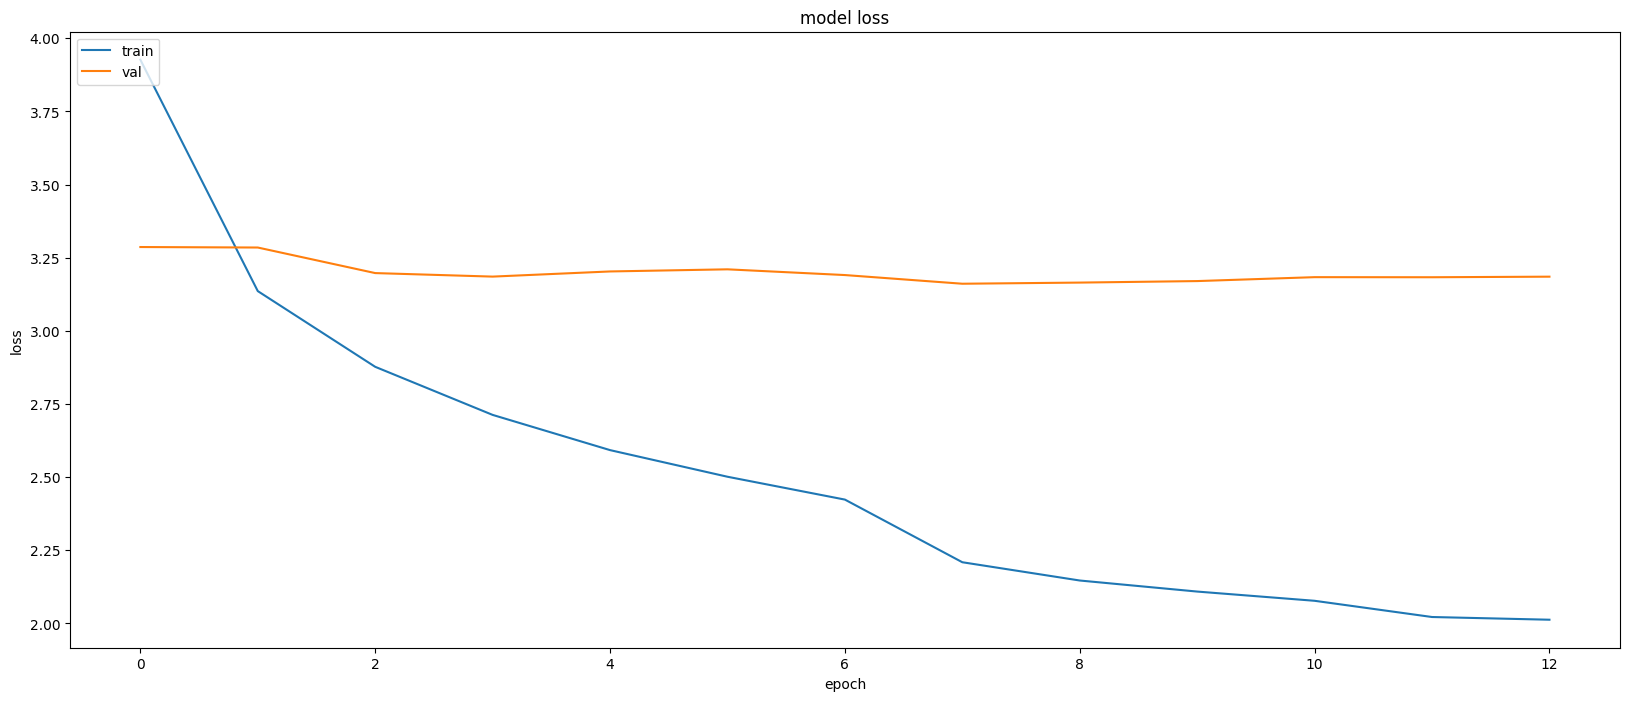

In [31]:
plt.figure(figsize=(20,8))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

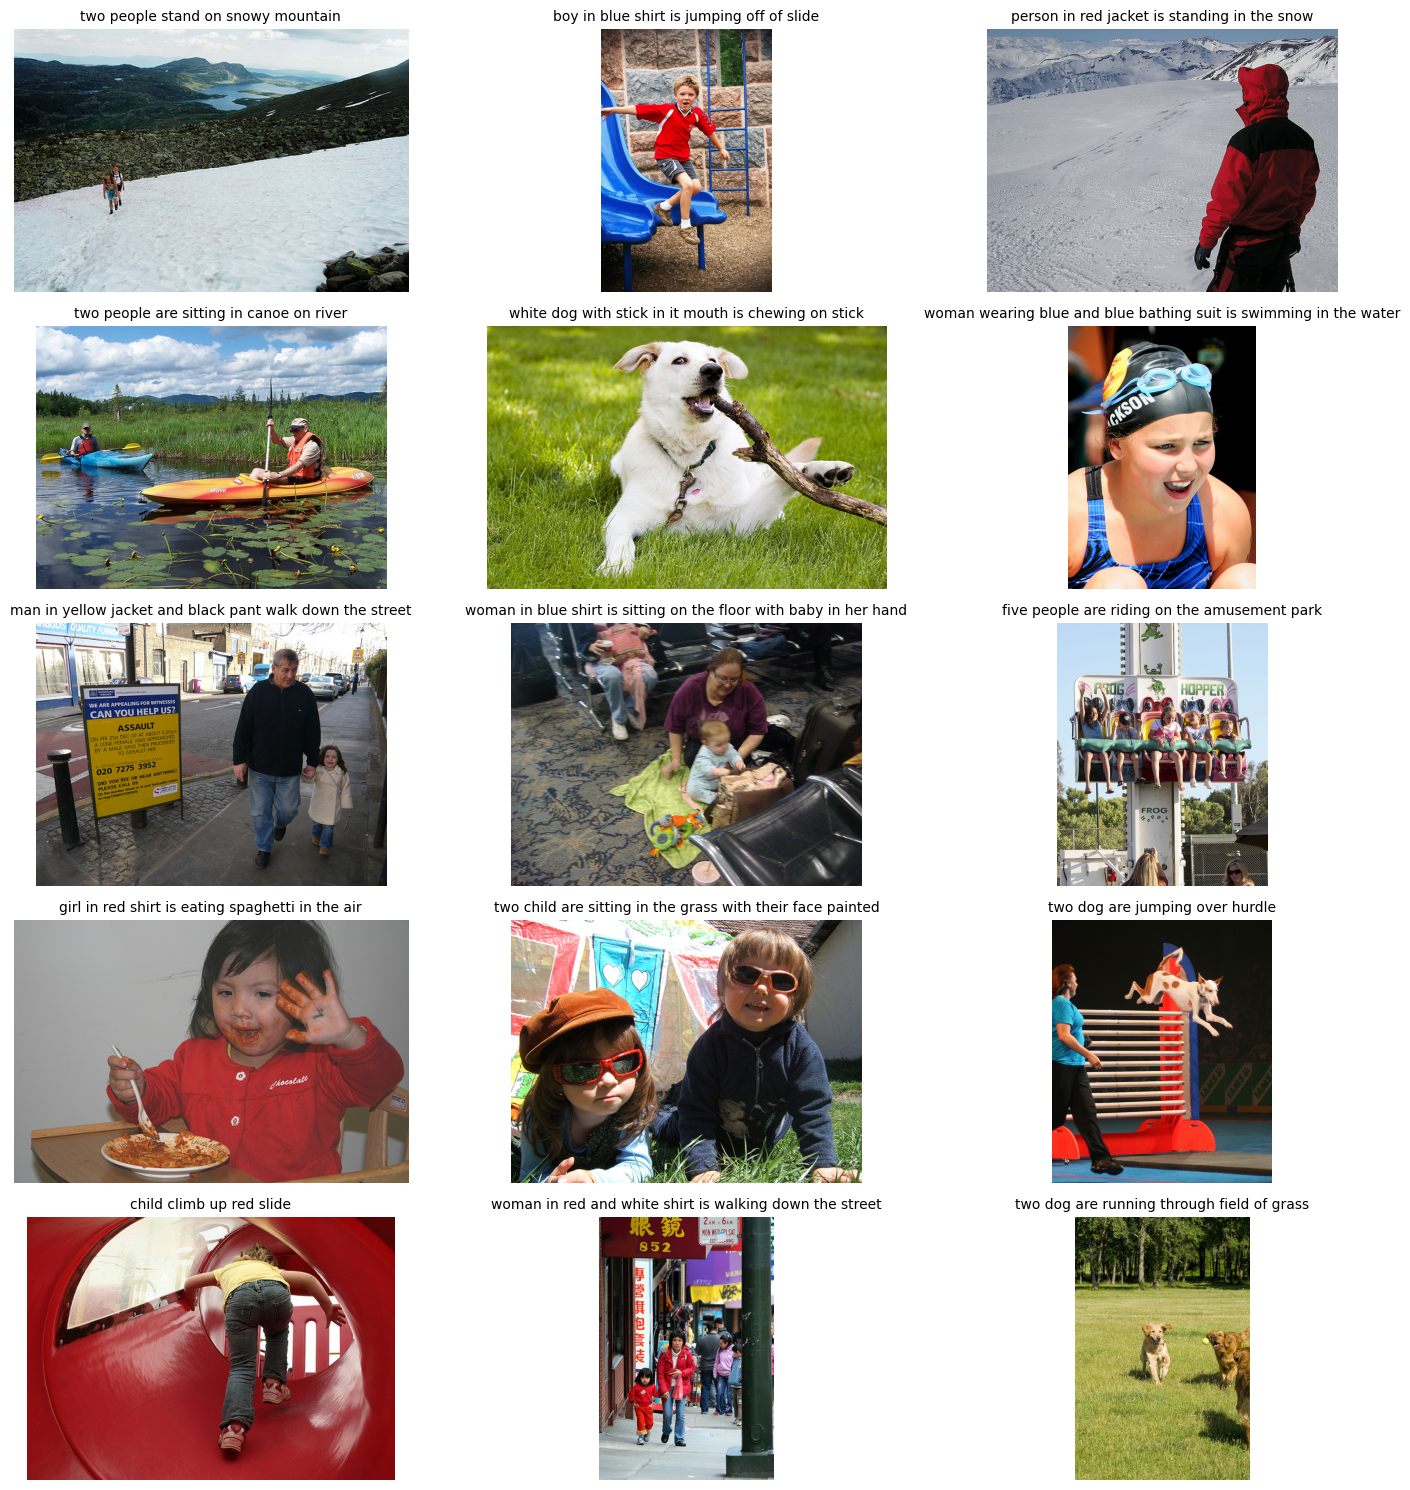

In [34]:
import matplotlib.pyplot as plt
import random
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from PIL import Image

def idx_to_word(index, tokenizer):
    """Convert index to word using the tokenizer's index_word dictionary."""
    return tokenizer.index_word.get(index, None)

def predict_caption(model, image_id, tokenizer, max_length, features):
    """
    Generate a caption for an image using the trained model.

    Parameters:
    - model: Trained image captioning model.
    - image_id: ID of the image (used to retrieve features).
    - tokenizer: Tokenizer for text processing.
    - max_length: Maximum length of the caption.
    - features: Dictionary containing extracted CNN features.

    Returns:
    - Generated caption as a string.
    """

    # Retrieve precomputed image features
    if image_id not in features:
        raise ValueError(f"Image ID {image_id} not found in extracted features.")

    image_feature = features[image_id].reshape(1, 512)  # Ensure correct shape

    # Start sequence with 'startseq' token (adjust based on your tokenizer)
    in_text = 'startseq'

    for _ in range(max_length):
        # Convert caption text to sequence of indices
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length, padding='post')  # Ensure right-padding

        # Predict the next word
        y_pred = model.predict([image_feature, sequence], verbose=0)
        y_pred = np.argmax(y_pred)  # Get highest probability word index

        # Convert predicted index to word
        word = idx_to_word(y_pred, tokenizer)

        if word is None:  # Skip unknown words
            continue

        # Append the word to the sequence
        in_text += " " + word

        # Stop if the 'endseq' token is predicted (adjust based on your tokenizer)
        if word == 'endseq':
            break

    # Remove 'startseq' and 'endseq' tokens before returning
    final_caption = in_text.replace("startseq", "").replace("endseq", "").strip()
    return final_caption

def display_predictions(model, test_images, tokenizer, max_length, features, num_samples=15):
    """
    Predict captions for randomly selected images from the test set and display them.

    Parameters:
    - model: Trained image captioning model.
    - test_images: List of test image filenames or IDs.
    - tokenizer: Tokenizer for text processing.
    - max_length: Maximum length of captions.
    - features: Dictionary of extracted image features.
    - num_samples: Number of random samples to display (default: 15).
    """

    # Select 15 random images from the test set
    sample_images = random.sample(test_images, num_samples)

    plt.figure(figsize=(15, 15))

    for i, image_id in enumerate(sample_images):
        # Generate caption
        caption = predict_caption(model, image_id, tokenizer, max_length, features)

        # Load and display image
        image_path = f"dataset/Images/{image_id}.jpg"  # Modify this path based on dataset structure
        img = Image.open(image_path)

        plt.subplot(5, 3, i + 1)  # Create a 5x3 grid
        plt.imshow(img)
        plt.axis("off")
        plt.title(caption, fontsize=10)

    plt.tight_layout()
    plt.show()

# Example usage
test_images = list(features.keys())  # Assuming 'features' dictionary contains test image IDs
display_predictions(model, test_images, tokenizer, max_length, features)